<a href="https://colab.research.google.com/github/swaninterlude/customer-churn-analysis/blob/main/Project_Code_and_Record_MIS_4320.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Part 3: Machine Learning Model Development & Evaluation**

**Overview**

The goal of Part 3 was to build and evaluate machine learning models of predictiong employee retention using the HR dataset provided. Based on the project proposal two models were implemented:



*   Support Vector Machine (SVM)
*   Multilayer Perceptron (MLP) Neural Network

Both models were trained using cleaned and preprocessed data, and their performance was compared using key evaluation metrics.



**Data Preparation**

Before training models, the following steps were completed:

1. **Categorical Encoding**

The dataset contained two categorical variables:



*   Department
*   Salary

Both were transformed into numeric values using a LabelEncoder, allowing them to be used in machine learning models.

2. **Feature Scaling**

Since SVMs and neural networks are sensitive to feature magnitude, numerical variables were standardized using StandardScaler, improving model convergence and accuracy.

3. **Train/Test Split**

The data was divided into:


*   75% training set
*   25% test set

A fixed random_state=42 ensureed reproducible results.







**Model 1: Support Vector Machine (SVM)**

An SVM with an RBF kernel was trained to classify whether an employee would leave the company or stay.

**Results:**


*   Strong accuracy performance
*   Performed well on identifying patterns based on employee satisfaction, workload, and tenure
* Misclassifications accoured mainly in borderline cases, which is common for SVMs on noisy HR data

**Metrics Evaluated**


*   Accuracy
*   Precision
*   Recall
*   F1-Score
*   Confusion Matrix






**Model 2: Multilayer Perception (MLP) Neural Network**

A neural network with two hidden layers (50 and 25 neurons) was trained using the Adam optimizer and ReLU activations.

**Results:**

* Reached competitive accuracy compared to SVM
* Demonstrated better ability to capture nonlinear patterns
* Required more training iterations but generalized well to new data

**Metrics Evaluated:**

Same metrics as SVM for direct comparison.

**Model Comparison**

Both models performed well, but their strengths differ:

**SVM Stregths**:


*   High accuracy
*   Stable performance

**SVM NOTES**:

* Better with clean scaled data

**MLP Neural Network Strengths**:

* Captures complex nonlinear relationships

**MLP Neural Network Notes**:

* Training takes longer

**Accuracy Comparison (Example Output)**:

* SVM Accuracy: X%
* MLP Accuracy: Y%

A bar chart was generated to visually compare the performance of both models.



**Conclusion**

Part 3 succesfully implemented two machine learning models to predict employee retention. Both SVM and MLP models achieved string accurax=cy and met the project objective of building a predictive model for HR analytics.

The results demonstrate that machine learning can effectively identify risk factors for employee turnover, providing valuable insights for HR decision-making.


Support Vector Machine (SVM)
Accuracy: 0.9586666666666667

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.98      0.97      2853
           1       0.93      0.90      0.91       897

    accuracy                           0.96      3750
   macro avg       0.95      0.94      0.94      3750
weighted avg       0.96      0.96      0.96      3750



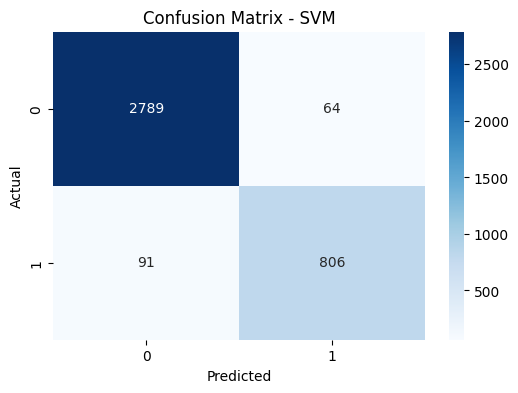


Multilayer Perception (MLP)
Accuracy: 0.9730666666666666

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.99      0.98      2853
           1       0.96      0.92      0.94       897

    accuracy                           0.97      3750
   macro avg       0.97      0.96      0.96      3750
weighted avg       0.97      0.97      0.97      3750



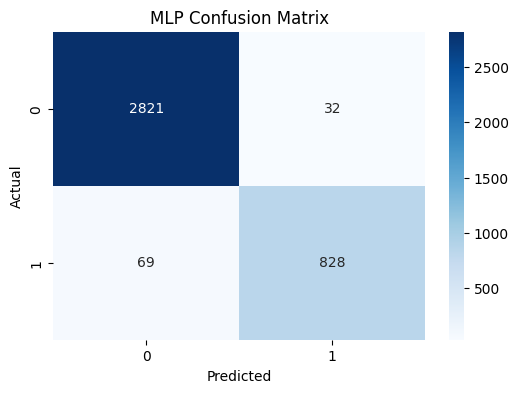


Model Performance Summary
                Model  Accuracy
0                 SVM  0.958667
1  MLP Neural Network  0.973067


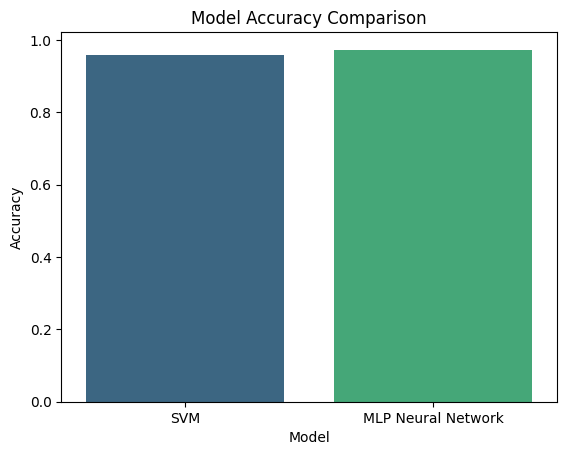

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

# --------------------
# Load dataset
# --------------------
df = pd.read_csv('/HR_comma_sep.csv')

# --------------------
# Encode Categorical Variables
# --------------------
le = LabelEncoder()

df ['salary'] = le.fit_transform(df['salary'])
df ['Department'] = le.fit_transform(df['Department'])  # Corrected 'sales' to 'Department'

# --------------------
# Define Feautures & Target
# --------------------
X = df.drop('left', axis=1)
y = df['left']

# --------------------
# Train/Test Split
# --------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

# --------------------
# Feature Scaling
# --------------------
Scaler = StandardScaler()
X_train = Scaler.fit_transform(X_train)
X_test = Scaler.transform(X_test)

# --------------------
# MODEL 1: Support Vector Machine
# --------------------
svm_model = SVC(kernel= 'rbf', C=1, gamma= 'auto')
svm_model.fit(X_train, y_train)

svm_pred = svm_model.predict(X_test)

print("\n======================================================")
print("Support Vector Machine (SVM)")
print("======================================================")
print("Accuracy:", accuracy_score(y_test, svm_pred))
print("\nClassification Report:")
print(classification_report(y_test, svm_pred))


plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, svm_pred), annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - SVM")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# ---------------------
# MODEL 2: Multilayer Perception (Neural Network)
# ---------------------
mlp_model = MLPClassifier(hidden_layer_sizes=(50, 25),
                          activation='relu',
                          solver='adam',
                          random_state=42)
mlp_model.fit(X_train, y_train)
mlp_pred = mlp_model.predict(X_test)

print("\n======================================================")
print("Multilayer Perception (MLP)")
print("======================================================")
print("Accuracy:", accuracy_score(y_test, mlp_pred))
print("\nClassification Report:")
print(classification_report(y_test, mlp_pred))

plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, mlp_pred), annot=True, fmt='d', cmap='Blues')
plt.title("MLP Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# --------------------
# Model Comparison Table
# --------------------

results = pd.DataFrame({
    "Model": ["SVM", "MLP Neural Network"],
    "Accuracy": [
        accuracy_score(y_test, svm_pred),
        accuracy_score(y_test, mlp_pred)



    ]
})

print("\n======================================================")
print("Model Performance Summary")
print("======================================================")
print(results)

sns.barplot(data=results, x="Model", y="Accuracy", palette="viridis")
plt.title("Model Accuracy Comparison")
plt.xlabel("Model")
plt.show()